# HCMUT-P4AIDS ASSIGNMENT 1 - EDA

## Tabular dataset: "younusmohamed/bank-telemarketing"



In [57]:
# Install dependencies
import pandas as pd
import kagglehub as KD
from kagglehub import KaggleDatasetAdapter as KDA
import seaborn as sns
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

In [58]:
file_path = "Banking_Call_Data.xlsx"
df = KD.dataset_load(
  KDA.PANDAS,
  "younusmohamed/bank-telemarketing",
  file_path
)

In [59]:
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [73]:
# df.isna().sum()
# df.duplicated().sum()
for col in df.select_dtypes(include='str').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f'{col}: {unknown_count} unknown ({unknown_count/len(df)*100:.2f}%)')

job: 288 unknown (0.64%)
education: 1857 unknown (4.11%)
contact: 13020 unknown (28.80%)
poutcome: 36959 unknown (81.75%)


In [61]:
# print(df.dtypes)
# df.describe()

In [62]:
# Get numerical attributes list (no binary)
num_attrs= ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
bin_attrs= ['default', 'housing', 'loan', 'y']
print(num_attrs)
print(f'Number of numerical attributes: {len(num_attrs)}')
print(f'Feature Statistics:')
for attr in num_attrs:
    print(f'{attr}:')
    print(f'Mean: {df[attr].mean()}')
    print(f'Median: {df[attr].median()}')
    print(f'Std: {df[attr].std()}')




['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
Number of numerical attributes: 6
Feature Statistics:
age:
Mean: 40.93621021432837
Median: 39.0
Std: 10.61876204097542
balance:
Mean: 1362.2720576850766
Median: 448.0
Std: 3044.7658291685175
duration:
Mean: 258.1630797814691
Median: 180.0
Std: 257.5278122651719
campaign:
Mean: 2.763840658246887
Median: 2.0
Std: 3.0980208832791694
pdays:
Mean: 40.19782796222158
Median: -1.0
Std: 100.12874599059835
previous:
Mean: 0.5803233726305546
Median: 0.0
Std: 2.3034410449312213


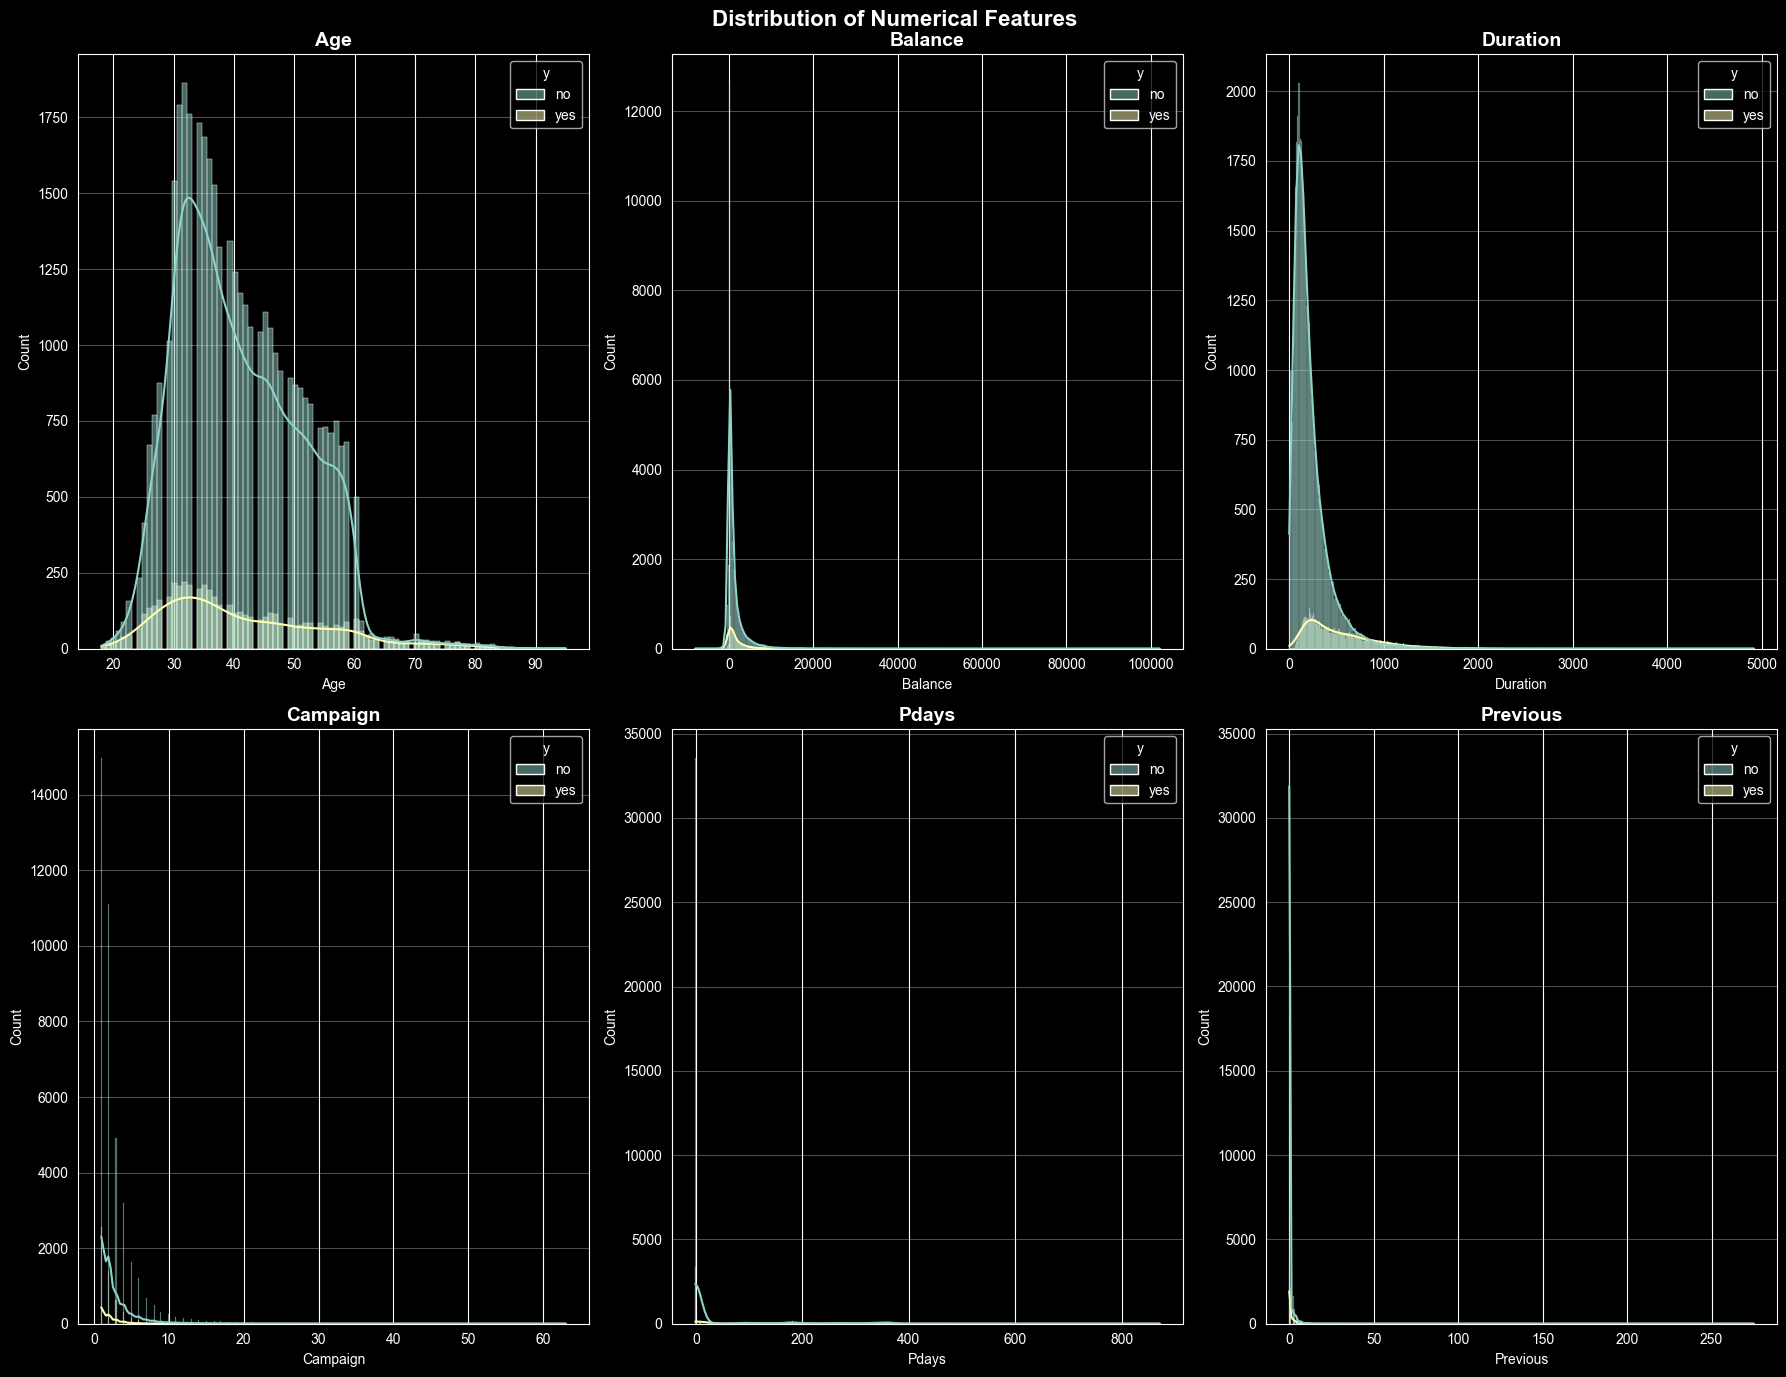

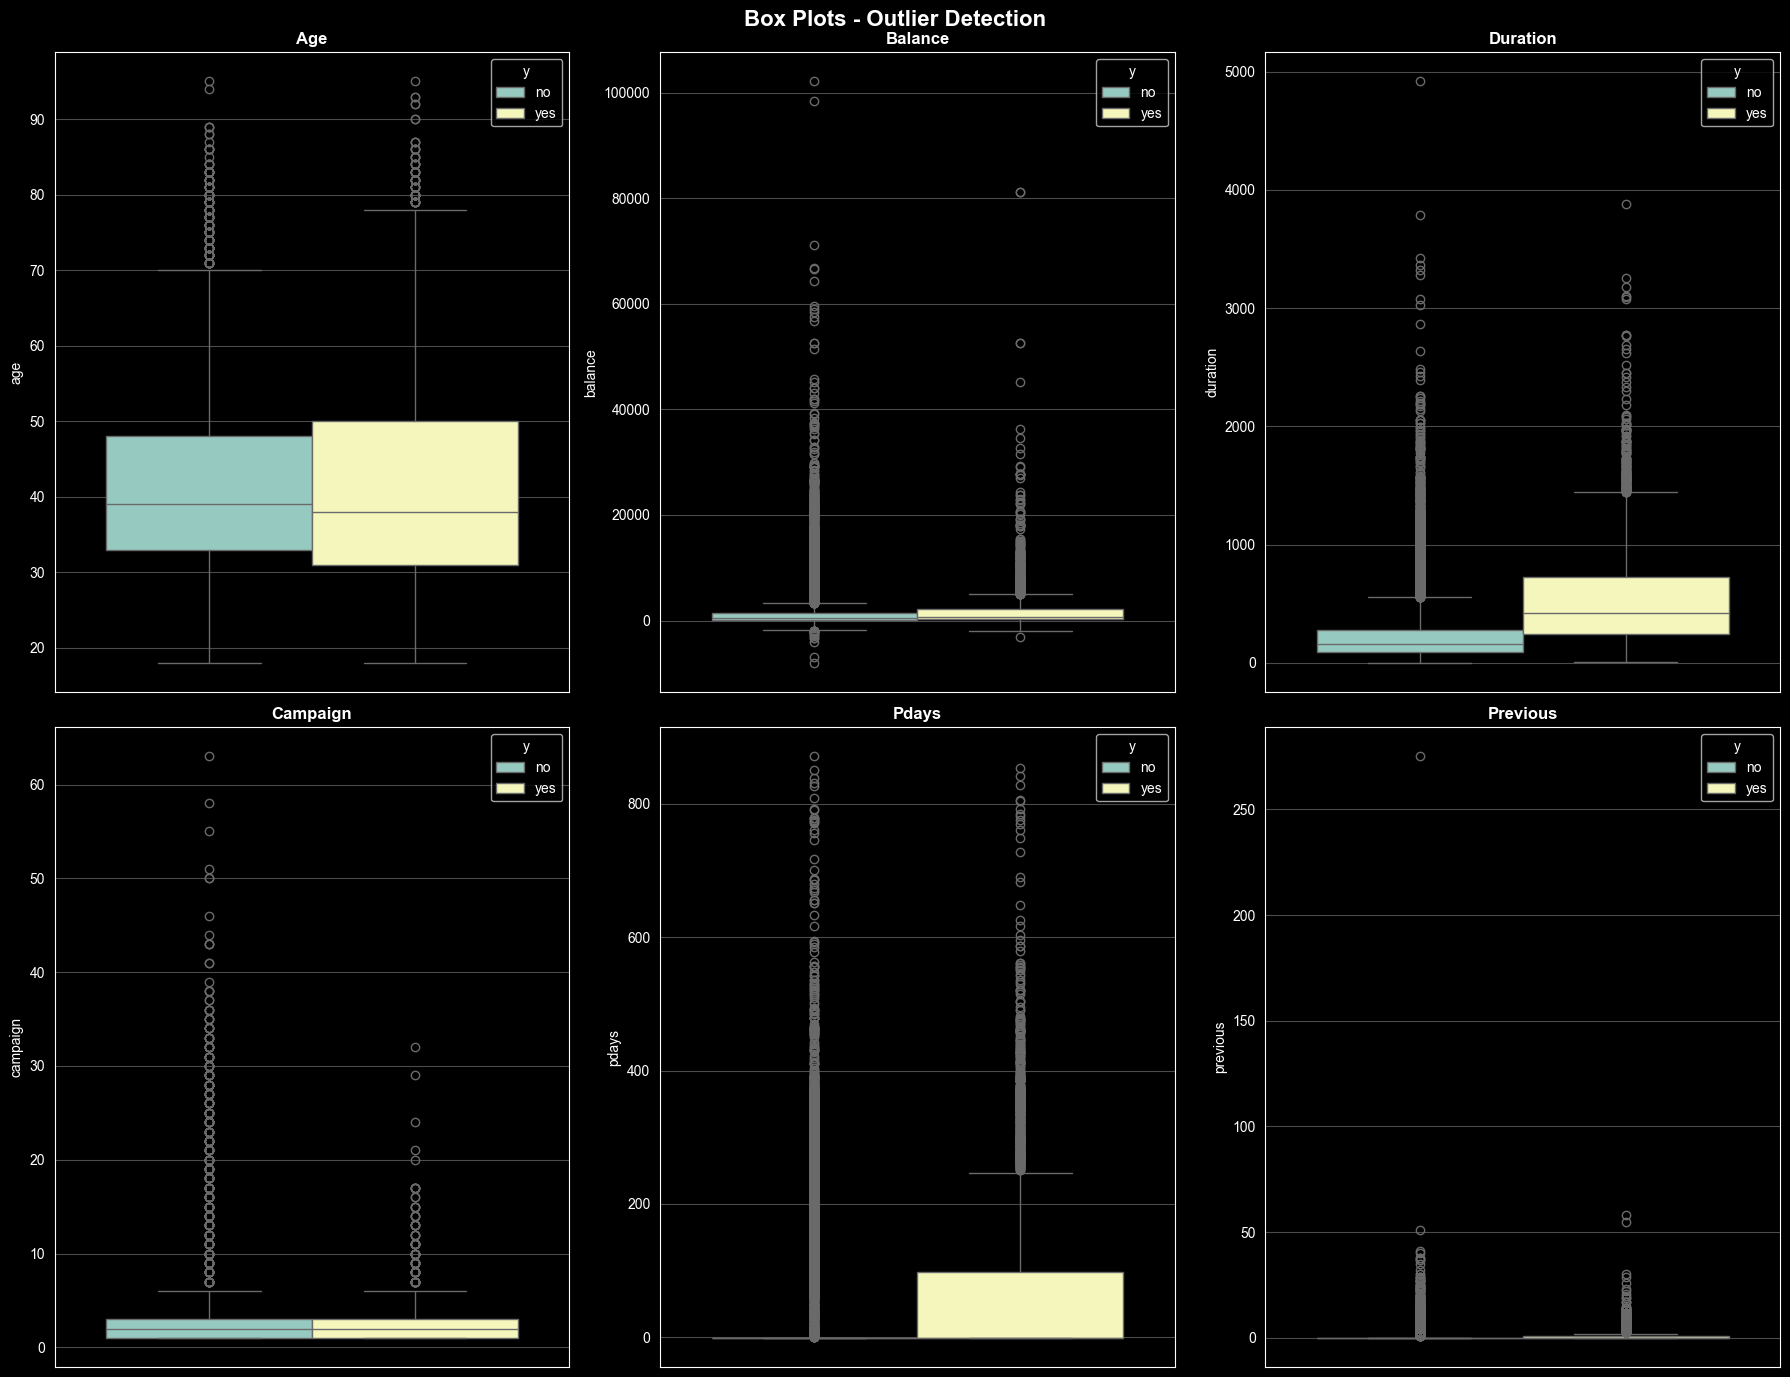

In [63]:
# Subplot division
sp_col = 3
sp_row = len(num_attrs) // sp_col + (len(num_attrs) % sp_col > 0)
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
for (idx, col) in enumerate(num_attrs):
    ax = axes[idx]
    sns.histplot(data=df, x= col, kde= True, ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
for j in range(len(num_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

#Box plots for outlier detection
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()  # <-- flatten the 2D array
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_attrs):
    ax = axes[idx]
    sns.boxplot(y=df[col], ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
for j in range(len(num_attrs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


default:
default
no     44396
yes      815
Name: count, dtype: int64
housing:
housing
yes    25130
no     20081
Name: count, dtype: int64
loan:
loan
no     37967
yes     7244
Name: count, dtype: int64
y:
y
no     39922
yes     5289
Name: count, dtype: int64


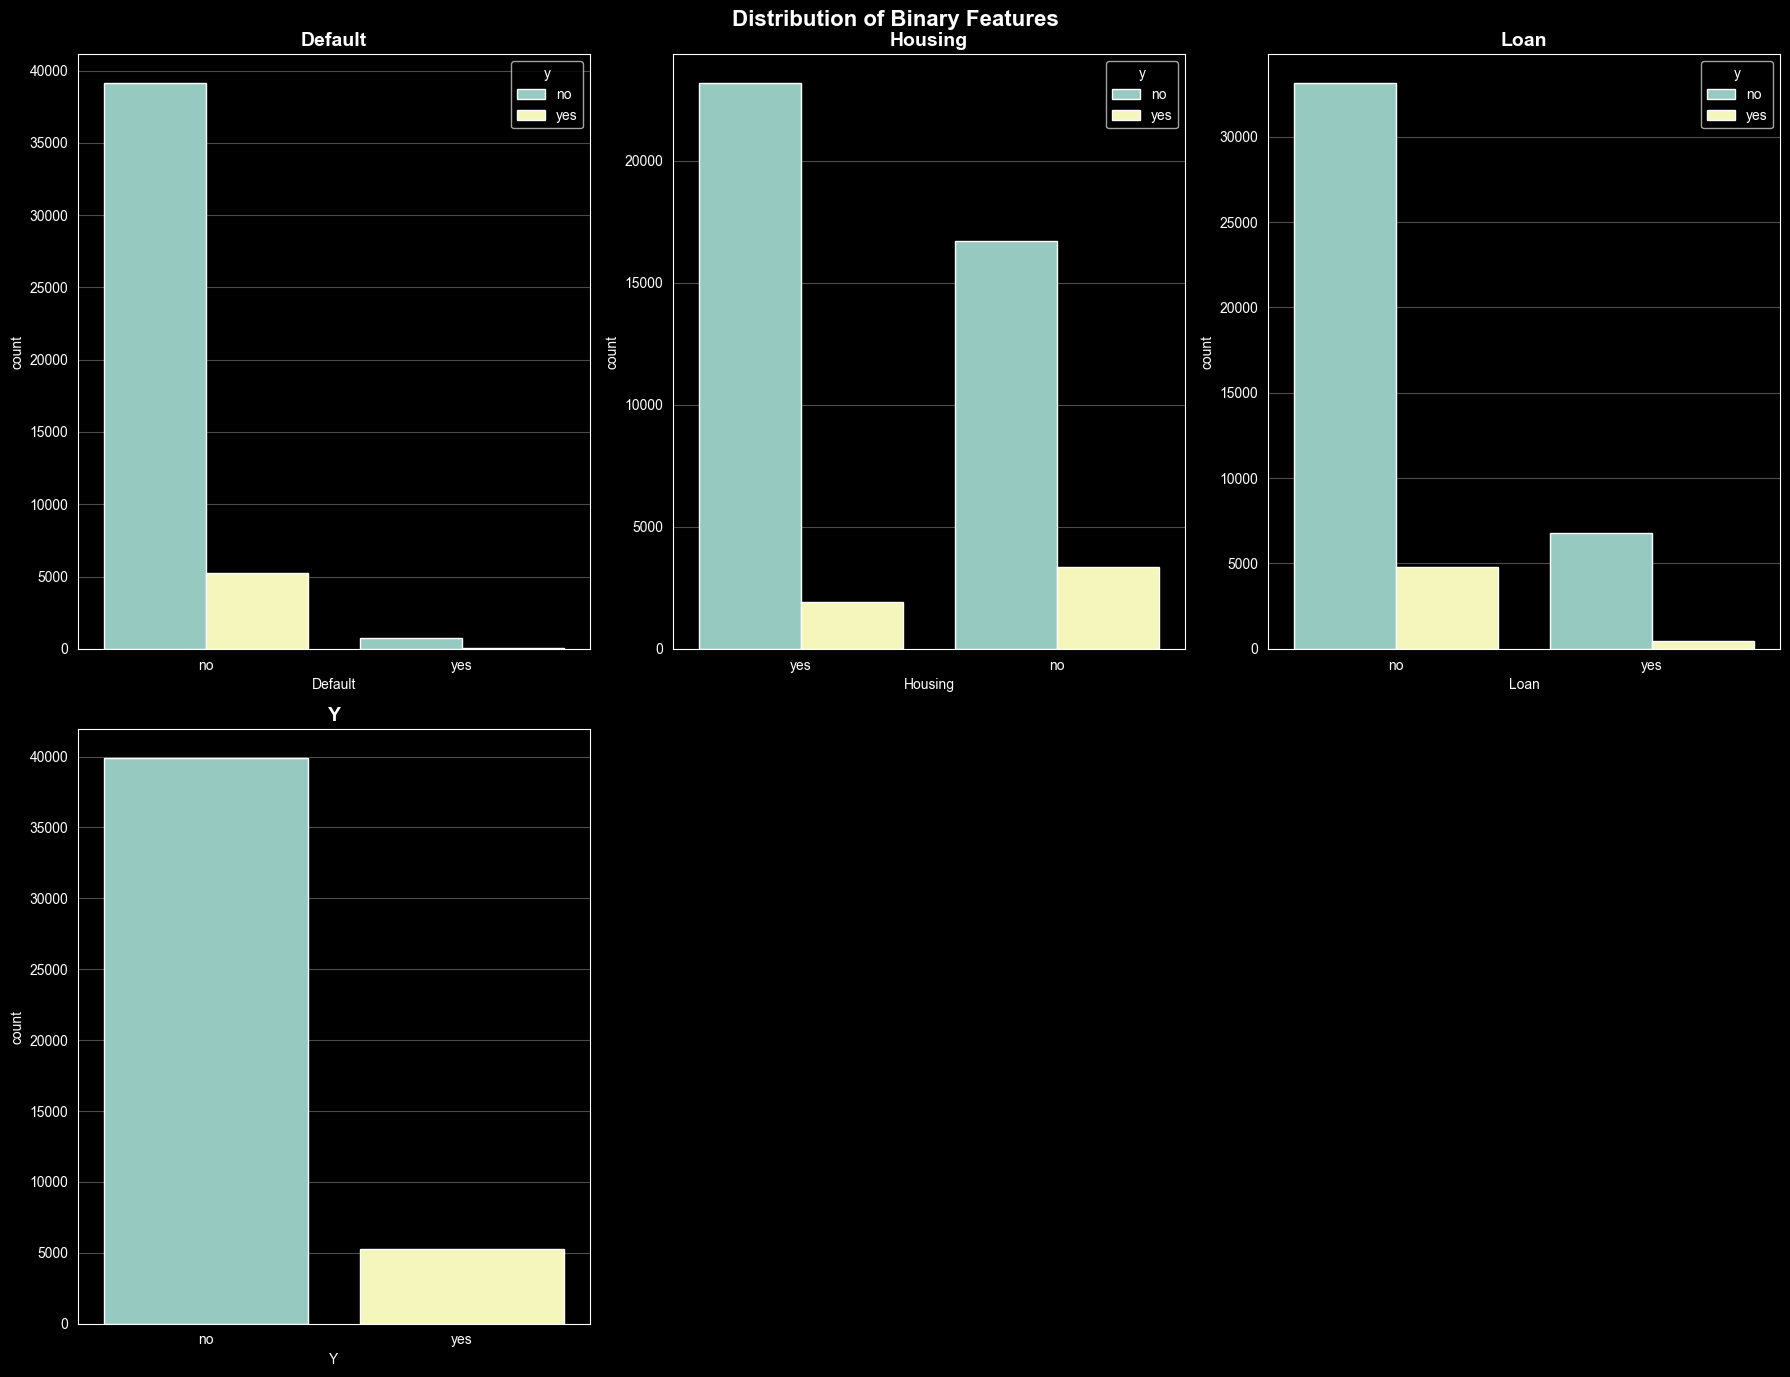

In [64]:
#binary attribute
for attr in bin_attrs:
    print(f'{attr}:')
    print(df[attr].value_counts())
sp_col = 3
sp_row = len(num_attrs) // sp_col + (len(num_attrs) % sp_col > 0)
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Distribution of Binary Features', fontsize=16, fontweight='bold')
for (idx, col) in enumerate(bin_attrs):
    ax = axes[idx]
    sns.countplot(data=df, x= col, ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
for j in range(len(bin_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()



In [65]:
#Categorical attributes
cat_attrs= ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
print(cat_attrs)

['job', 'marital', 'education', 'contact', 'month', 'poutcome']


Value Counts for Categorical Features:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


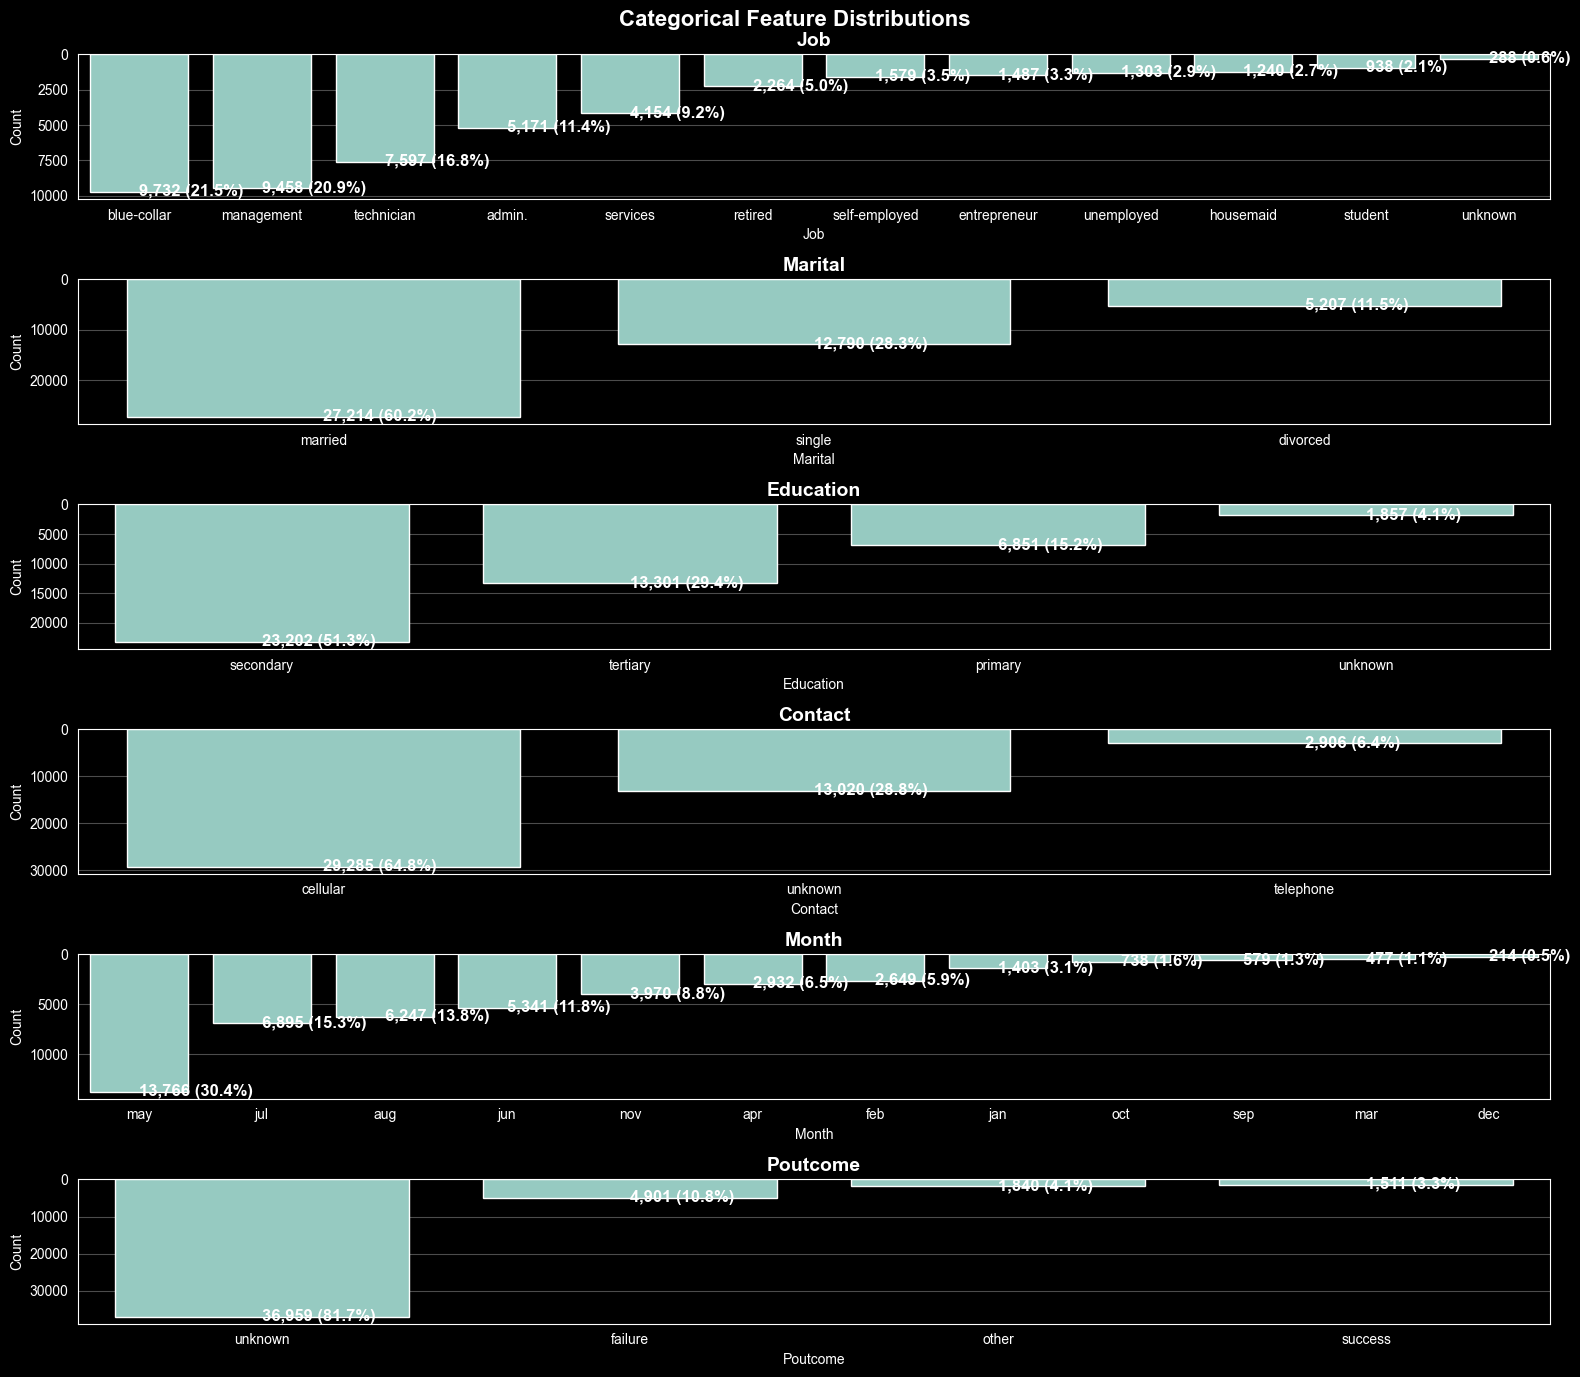

In [66]:
#get value counts for categorical attributes
print('Value Counts for Categorical Features:')
val_counts = [df[attr].value_counts() for attr in cat_attrs]
for i, attr in enumerate(cat_attrs):
    print(val_counts[i])
#plot value counts for categorical attributes
fig, axes = plt.subplots(nrows=len(cat_attrs), ncols=1, figsize=(16, 14))
axes = axes.flatten()
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')
for i, attr in enumerate(cat_attrs):
    ax = axes[i]
    sns.barplot(x=val_counts[i].index, y=val_counts[i].values, ax=ax)
    ax.set_title(attr.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(attr.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.invert_yaxis()
    ax.grid(axis='y', alpha=0.3)
    total = val_counts[i].sum()
    for x,y in enumerate(val_counts[i].values):
         ax.text(x, y+0.05, f'{y:,} ({y/total*100:.1f}%)',va='center', fontsize=12, fontweight='bold')
for j in range(len(cat_attrs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()




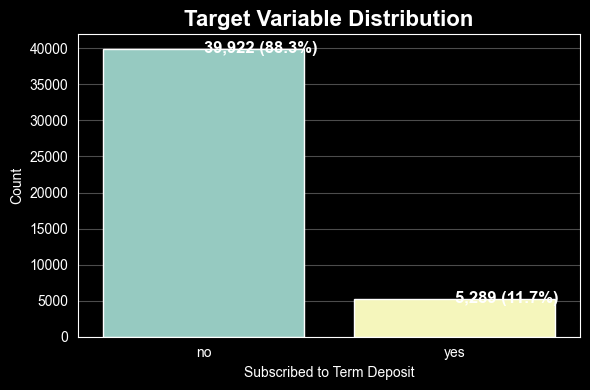

Imbalance Ratio (No/Yes): 7.55


In [67]:
#Target value distribution
target_counts = df['y'].value_counts()
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x= 'y', hue= df['y'])
plt.title('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
total = target_counts.sum()
for x,y in enumerate(target_counts.values):
    plt.text(x, y+0.05, f'{y:,} ({y/total*100:.1f}%)', va='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
#print imbalance ratio
imbalance_ratio = target_counts.max() / target_counts.min()
print(f'Imbalance Ratio (No/Yes): {imbalance_ratio:.2f}')


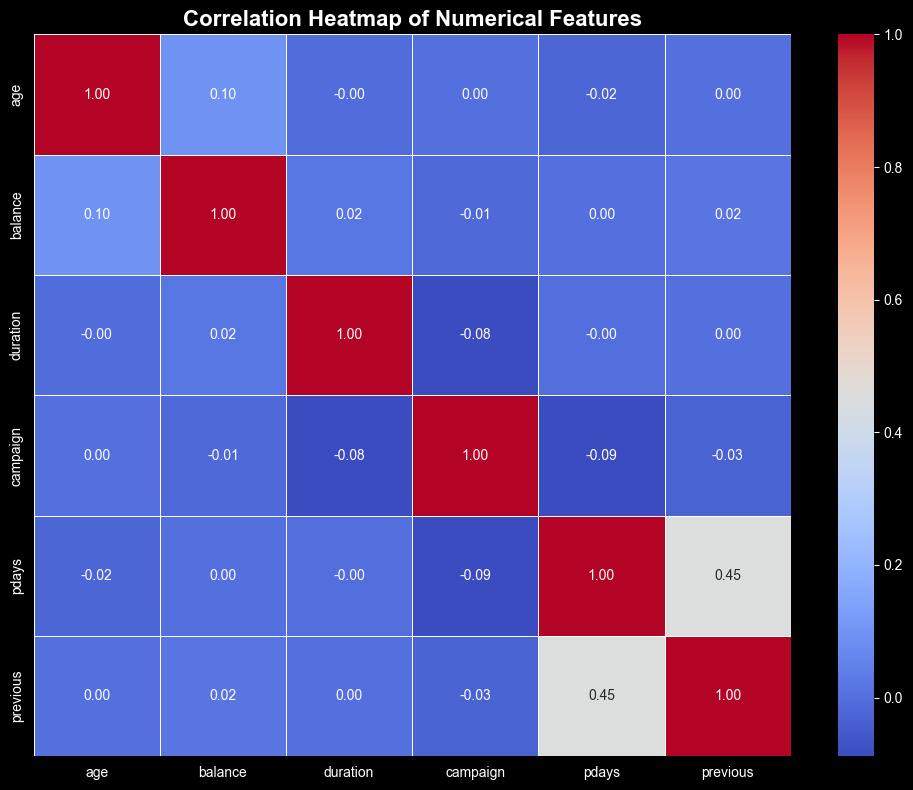

In [68]:
#correlation heatmap for numerical and binary attributes
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_attrs].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

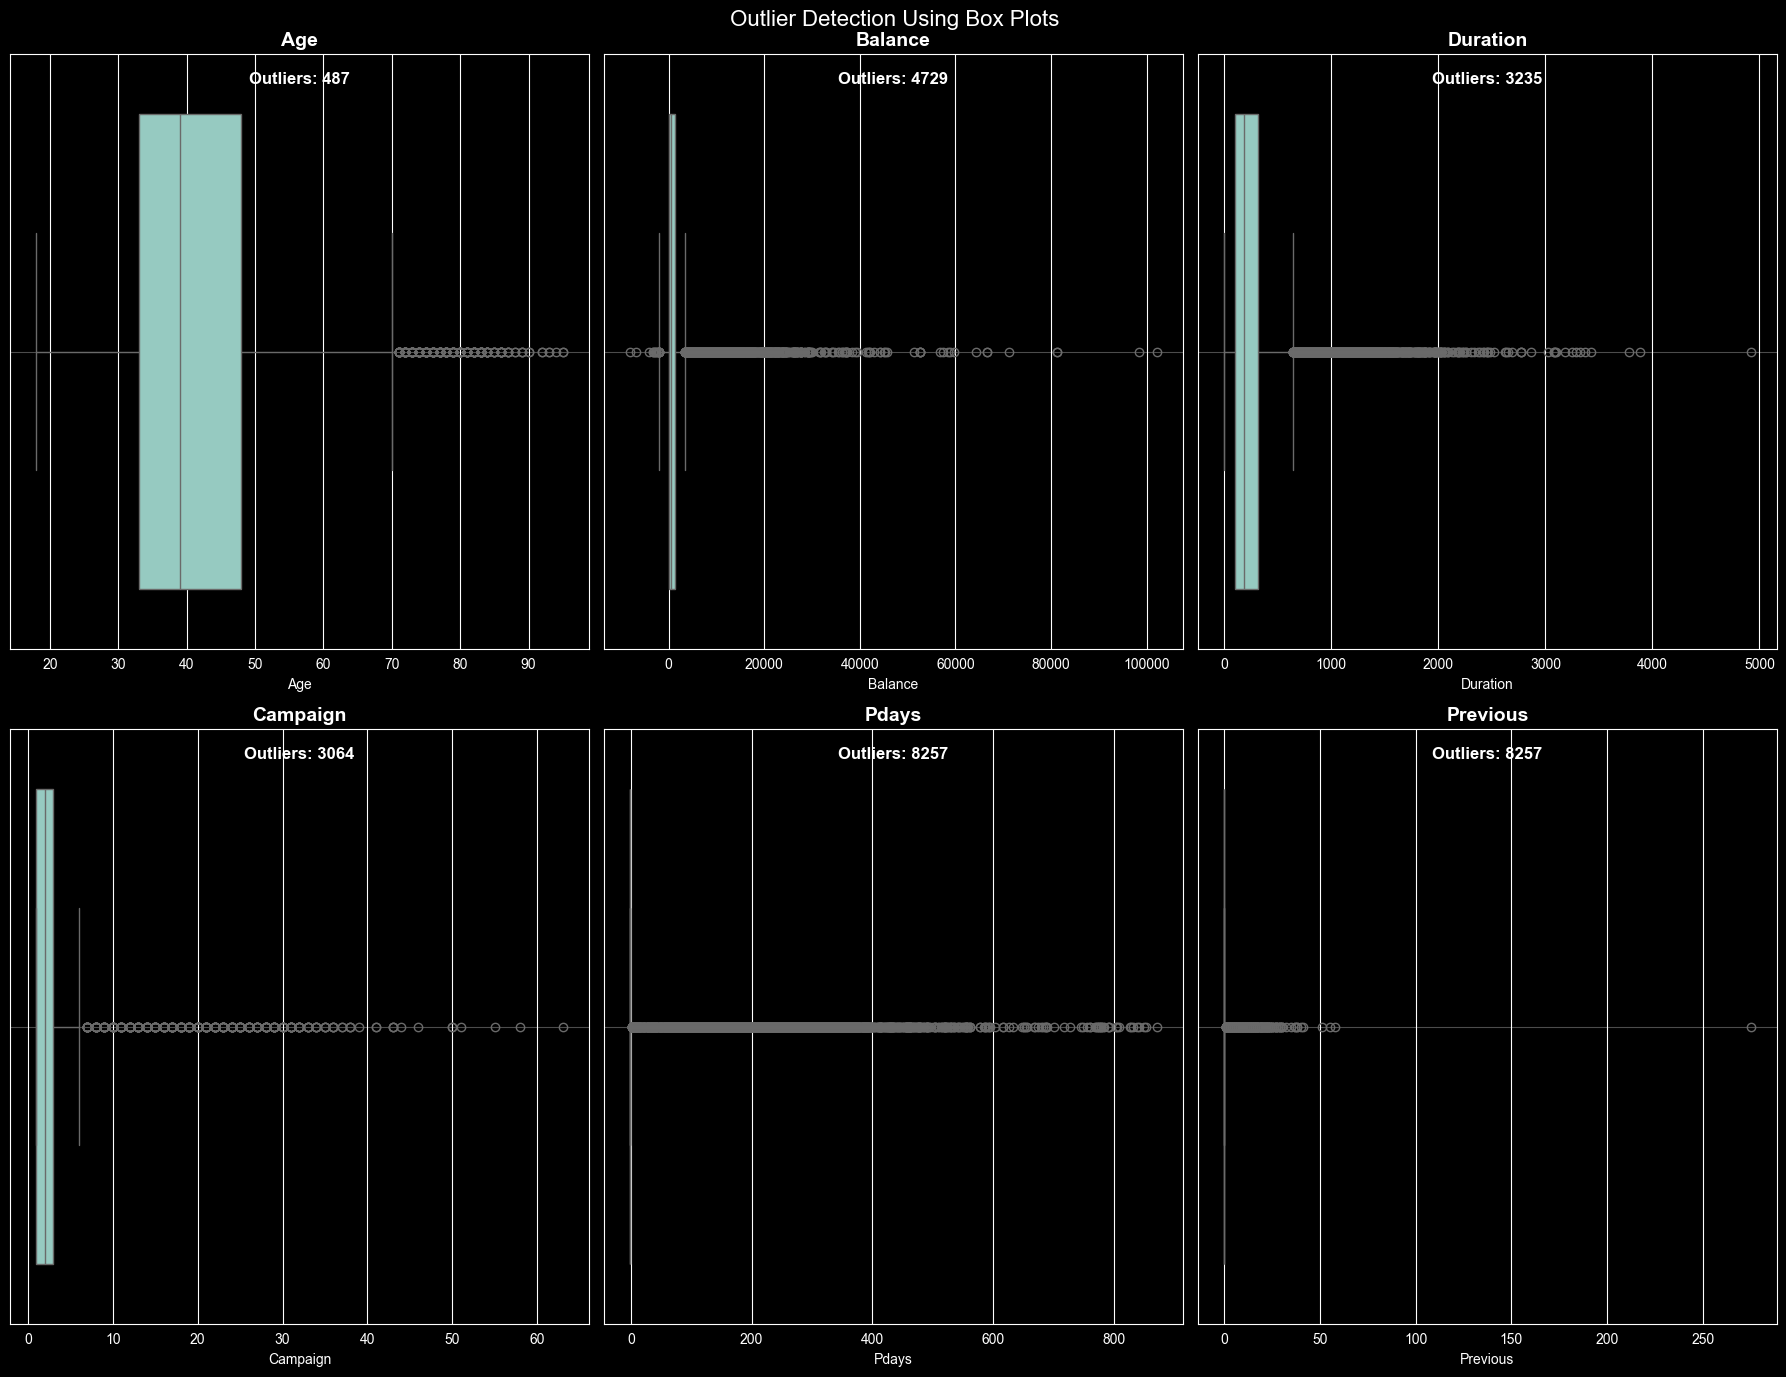

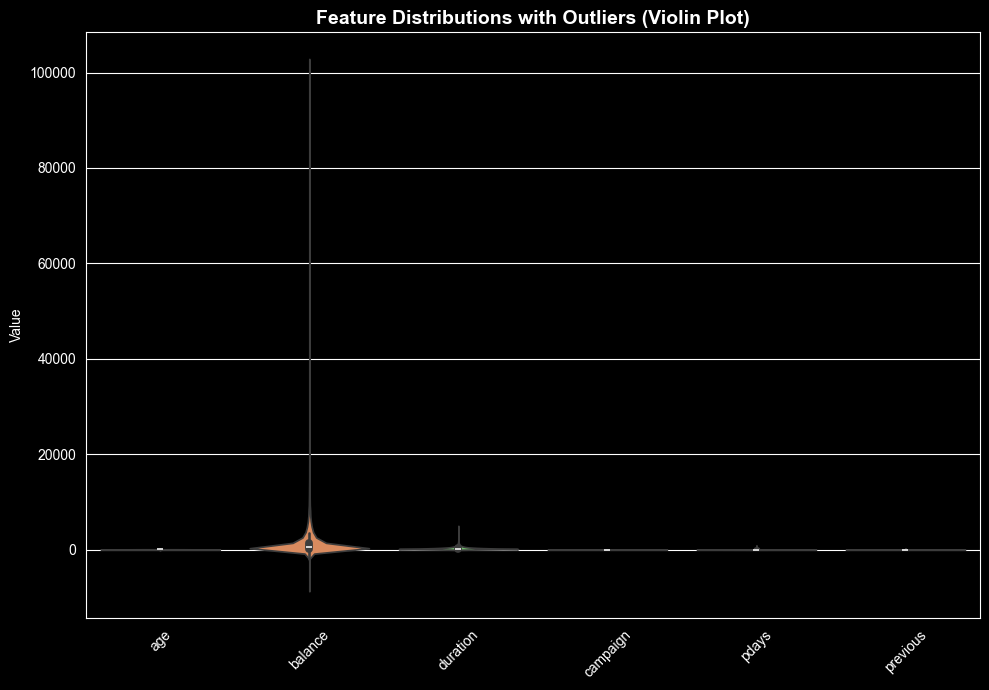

age: 487
Outlier percentage: 1.08%
balance: 4729
Outlier percentage: 10.46%
duration: 3235
Outlier percentage: 7.16%
campaign: 3064
Outlier percentage: 6.78%
pdays: 8257
Outlier percentage: 18.26%
previous: 8257
Outlier percentage: 18.26%


In [69]:
#Outlier detection for numerical attributes
sp_col = 3
sp_row = len(num_attrs) // sp_col + (len(num_attrs) % sp_col > 0)
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Outlier Detection Using Box Plots', fontsize=16)
for idx, col in enumerate(num_attrs):
    ax = axes[idx]
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    ax.text(0.5, 0.95, f'Outliers: {outliers}',transform=ax.transAxes, ha='center', fontsize=12, fontweight='bold')
for j in range(len(num_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()
#violin plot for numerical attributes
fig, ax= plt.subplots(figsize=(10,7))
sns.violinplot(data=df[num_attrs], palette='muted', ax=ax)
ax.set_title('Feature Distributions with Outliers (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#table of outliers info
for idx, col in enumerate(num_attrs):
    outlier_count = len(df[(df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75) - df[col].quantile(0.25))) | (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75) - df[col].quantile(0.25)))])
    print(f'{col}: {outlier_count}')
    print(f'Outlier percentage: {outlier_count/len(df):.2%}')



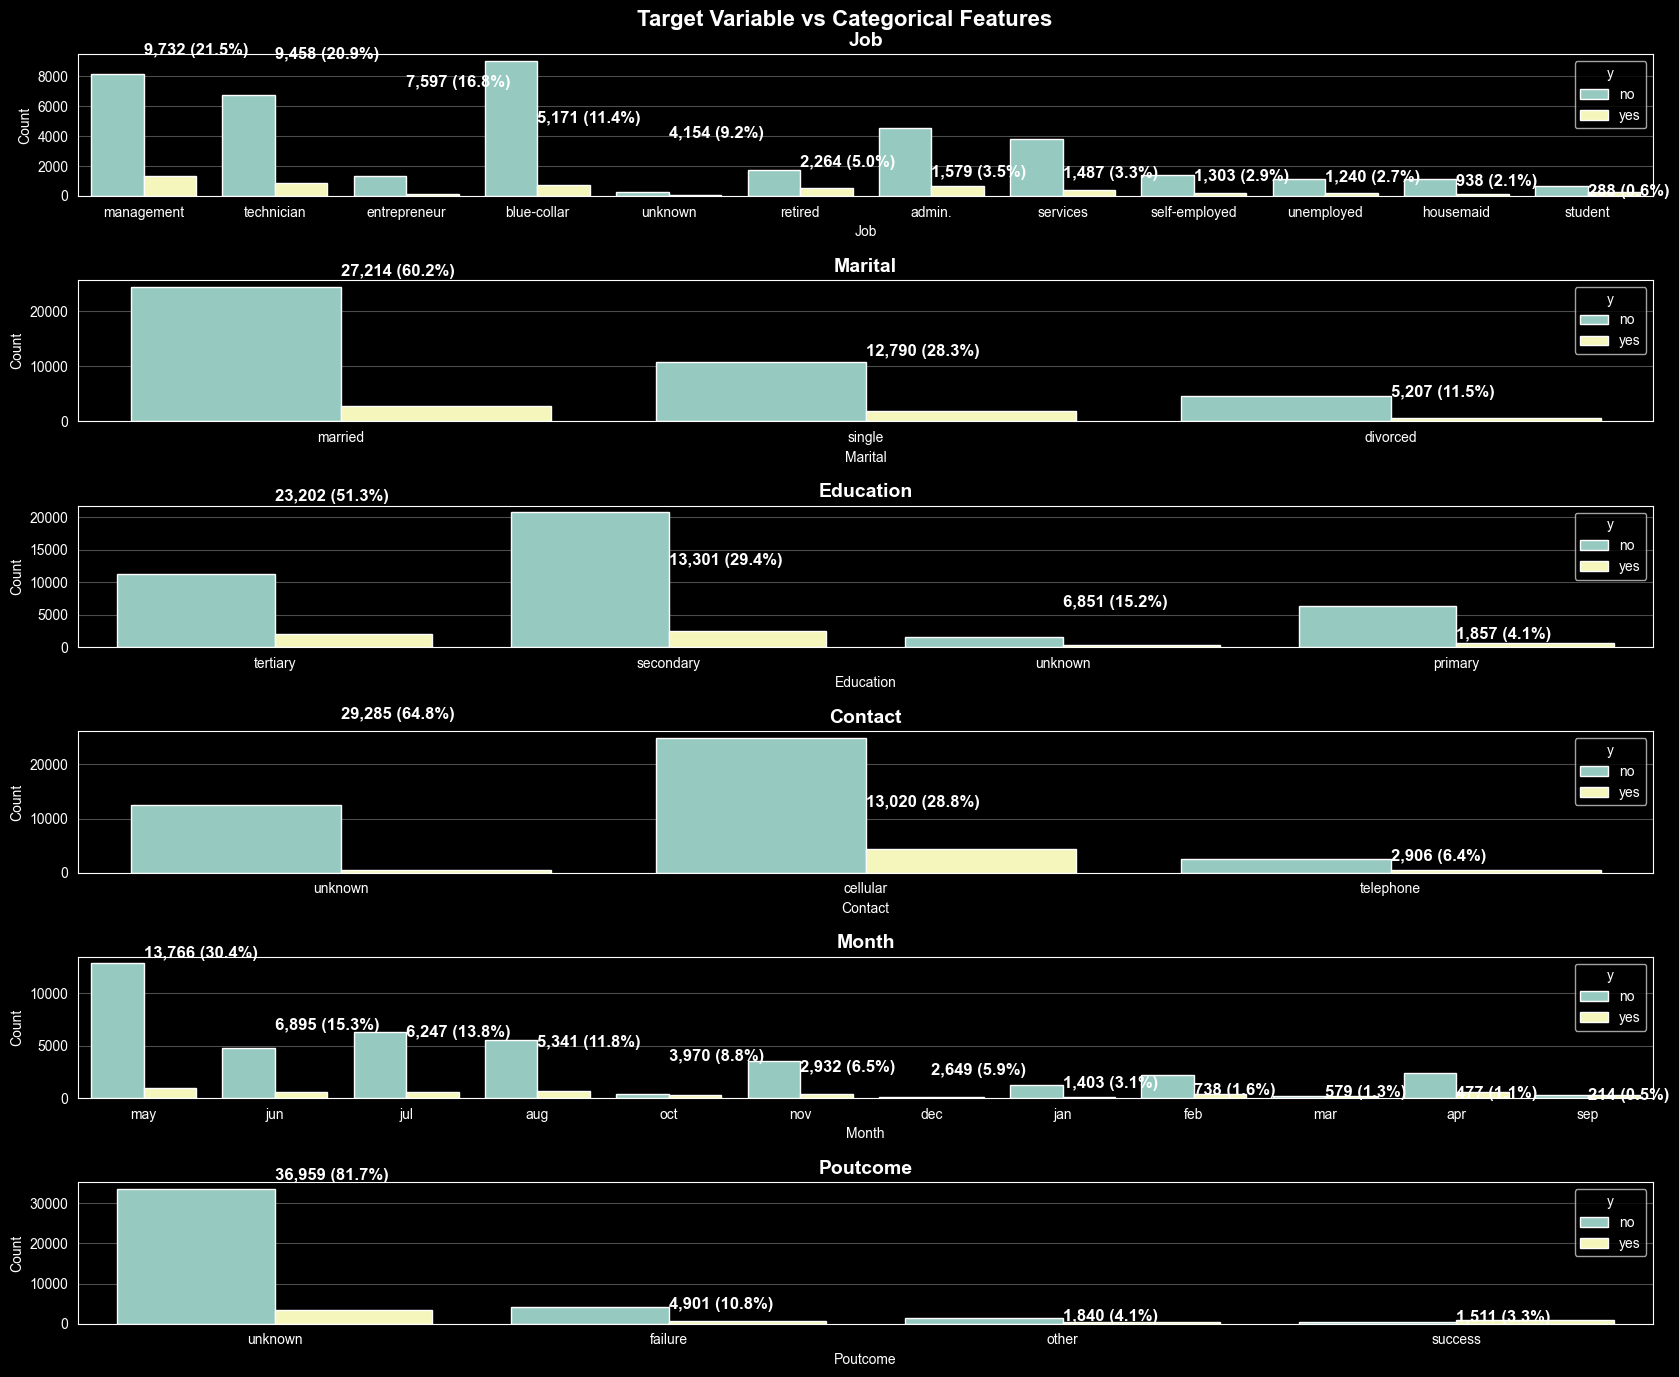

In [70]:
#target vs categorical attributes
fig, axes = plt.subplots(nrows=len(cat_attrs), ncols=1, figsize=(17, 14))
axes = axes.flatten()
fig.suptitle('Target Variable vs Categorical Features', fontsize=16, fontweight='bold')
for i, attr in enumerate(cat_attrs):
    ax = axes[i]
    sns.countplot(data=df, x=attr, hue='y', ax=ax)
    ax.set_title(attr.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(attr.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    total = df[attr].value_counts().sum()
    for x,y in enumerate(df[attr].value_counts().values):
        ax.text(x, y+0.05, f'{y:,} ({y/total*100:.1f}%)', va='center', fontsize=12, fontweight='bold')
for j in range(len(cat_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [71]:
#show data with y = 1
df.query('y == "yes"').head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [72]:
df.query('y == "no"').head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# KEY INSIGHTS

## 1. Severely Imbalanced Target Variable
The dataset is highly imbalanced: **39,922 "no"** vs **5,289 "yes"** (Ratio no/yes = **7.6**).

## 2. No Missing Values, No Duplicates
Data is clean. No further treatment is needed for missing values or duplicates.

## 3. Heavy Skewness & Outliers
- **balance:** Mean is 1,362 but median is only 448, indicating strong right skew. A small number of high-balance clients pull the mean up significantly.
- **duration** (call duration): Mean 258s vs median 180s, also right-skewed. This is the most predictive feature, but it's only known after the call ends, making it a **data leakage risk**, so it shouldn't be used in a real-world predictive model.
- **campaign:** Mean ~2.76, median 2. Most clients were contacted only 1-3 times, but outliers exist with very high contact counts.
- **pdays:** Median is -1, meaning the majority of clients were never previously contacted. The mean of 40 is misleading due to this unusual distribution.
- **previous:** Mean 0.58, most clients have zero prior contacts.

## 4. Binary Features
- **default:** 44,396 "no" vs only 815 "yes". Almost no one has credit in default, so this feature has extremely low variance and likely provides little discriminative power.
- **housing:** Fairly balanced (25K yes / 20K no), making it a potentially useful predictor.
- **loan:** 38K "no" vs 7.2K "yes", most clients don't have a personal loan.

## 5. Categorical Features
- **job:** Blue-collar (9.7K) and management (9.5K) dominate. Students and retirees tend to show higher subscription rates relative to their group size.
- **marital:** Married clients are the majority (27K). Single clients tend to have a relatively higher conversion rate.
- **education:** Secondary education makes up ~51%, tertiary ~29%. Higher education correlates positively with subscription.
- **contact:** A large proportion is "unknown".
- **month:** May has the highest call volume. Certain months show noticeably better conversion rates.
- **poutcome:** Mostly "unknown" (tied to pdays = -1). However, when poutcome = "success" (previous campaign was successful), the probability of subscribing this time is very high, so this is the **single strongest predictor**.

## 6. Correlation Between Numerical Features
The heatmap shows generally **low correlations** across numerical features, which is good news for linear models. The notable exception is the **pdays-previous** pair, which has a positive correlation (logically, if a client was previously contacted, both values are non-default).

## 7. Key Takeaways Moving Forward
1. **Handling class imbalance** is mandatory.
2. Consider **dropping `duration`** if you want a model applicable before the call happens.
3. **`poutcome`** carries the strongest predictive signal.
4. **Outlier treatment** is needed for `balance`, `campaign`, and `duration`.
5. **"Unknown" values** across multiple features (`contact`, `education`, `poutcome`) should be treated carefully as structured missingness rather than simply dropped.